In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
from collections import Counter

# Set paths
BASE_DIR = os.path.expanduser('~/Desktop/phishing-debate-detector')
DATA_DIR = os.path.join(BASE_DIR, 'data')

print("Notebook 1: Data Preparation")
print("=" * 50)

Matplotlib is building the font cache; this may take a moment.


Notebook 1: Data Preparation


In [2]:
# Load the 500-email dataset
df = pd.read_csv(os.path.join(DATA_DIR, 'processed/emails_dataset.csv'))

print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nLabel distribution:")
print(df['label_text'].value_counts())
print(f"\nFirst 3 rows:")
df.head(3)

Shape: (500, 5)

Columns: ['id', 'subject', 'body', 'label', 'label_text']

Label distribution:
label_text
legitimate    250
phishing      250
Name: count, dtype: int64

First 3 rows:


,id,subject,body,label,label_text
0,legit_208,"Re: Economist: Internet models, viral spread, ...",The structure of the Internet has never been a...,0,legitimate
1,legit_166,A Living Memorial,-----BEGIN PGP SIGNED MESSAGE----- Hash: SHA1 ...,0,legitimate
2,legit_225,Re: Problem building lame-3.92-fr5.src.rpm on RH8,"Once upon a time, Coy wrote : > I can't seem t...",0,legitimate


In [4]:
# Clean text: strip HTML remnants, normalize whitespace, handle encoding
def clean_text(text):
    if pd.isna(text):
        return ''
    text = str(text)
    text = text.replace('\n', ' ').replace('\r', ' ').replace('\t', ' ')
    text = ' '.join(text.split())
    return text.strip()

df['subject'] = df['subject'].apply(clean_text)
df['body'] = df['body'].apply(clean_text)

# Combine subject + body into email_text (used by detectors later)
df['email_text'] = df.apply(
    lambda r: "Subject: " + r['subject'] + "\n\n" + r['body'], axis=1
)

# Add email_type column (needed for the roadmap schema)
df['email_type'] = df['label_text'].map({
    'phishing': 'phishing_original',
    'legitimate': 'legitimate'
})

# Add placeholder columns for adversarial rewriting (Notebook 2 will fill these)
df['rewrite_level'] = 0
df['original_id'] = df['id']

print("Columns after cleaning:")
print(list(df.columns))
print("")
print("email_type distribution:")
print(df['email_type'].value_counts())
print("")
avg_len = df['email_text'].str.len().mean()
min_len = df['email_text'].str.len().min()
max_len = df['email_text'].str.len().max()
print("Avg email length: " + str(round(avg_len)) + " chars")
print("Min: " + str(min_len) + ", Max: " + str(max_len))

Columns after cleaning:
['id', 'subject', 'body', 'label', 'label_text', 'email_text', 'email_type', 'rewrite_level', 'original_id']

email_type distribution:
email_type
legitimate           250
phishing_original    250
Name: count, dtype: int64

Avg email length: 1232 chars
Min: 98, Max: 3095


In [5]:
from sklearn.model_selection import train_test_split

# Create train/test split (80/20, stratified by label)
train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['label']
)

print("Train set: " + str(train_df.shape[0]) + " emails")
print("  Phishing: " + str(len(train_df[train_df['label']==1])))
print("  Legitimate: " + str(len(train_df[train_df['label']==0])))
print("")
print("Test set: " + str(test_df.shape[0]) + " emails")
print("  Phishing: " + str(len(test_df[test_df['label']==1])))
print("  Legitimate: " + str(len(test_df[test_df['label']==0])))

# Save all files
out_dir = os.path.join(DATA_DIR, 'processed')
df.to_csv(os.path.join(out_dir, 'combined_dataset.csv'), index=False)
train_df.to_csv(os.path.join(out_dir, 'train.csv'), index=False)
test_df.to_csv(os.path.join(out_dir, 'test.csv'), index=False)

print("")
print("Files saved:")
for f in ['combined_dataset.csv', 'train.csv', 'test.csv']:
    size = os.path.getsize(os.path.join(out_dir, f))
    print("  " + f + " (" + str(round(size/1024)) + " KB)")

Train set: 400 emails
  Phishing: 200
  Legitimate: 200

Test set: 100 emails
  Phishing: 50
  Legitimate: 50

Files saved:
  combined_dataset.csv (1229 KB)
  train.csv (983 KB)
  test.csv (246 KB)


In [6]:
# Load BEC conversation threads
bec_path = os.path.join(DATA_DIR, 'bec_threads/bec_conversations.json')
with open(bec_path, 'r') as f:
    bec_threads = json.load(f)

print("BEC Threads: " + str(len(bec_threads)))
print("")

# Summary by pattern
patterns = {}
for t in bec_threads:
    p = t['pattern']
    patterns[p] = patterns.get(p, 0) + 1

print("Threads by attack pattern:")
for p, c in sorted(patterns.items()):
    print("  " + p + ": " + str(c))

print("")
total_emails = sum(len(t['emails']) for t in bec_threads)
print("Total individual emails across all threads: " + str(total_emails))

# Show one example thread
print("")
print("Example thread (bec_001):")
for email in bec_threads[0]['emails']:
    tag = "CLEAN" if not email['is_phishing'] else "PHISH"
    print("  Turn " + str(email['turn']) + " [" + tag + "]: " + email['subject'])

BEC Threads: 19

Threads by attack pattern:
  credential_harvest: 2
  data_exfiltration: 2
  foot_in_door: 3
  legitimate: 3
  payroll_diversion: 2
  slow_burn: 2
  vendor_impersonation: 2
  wire_transfer: 3

Total individual emails across all threads: 40

Example thread (bec_001):
  Turn 1 [CLEAN]: Quick question
  Turn 2 [PHISH]: Re: Quick question


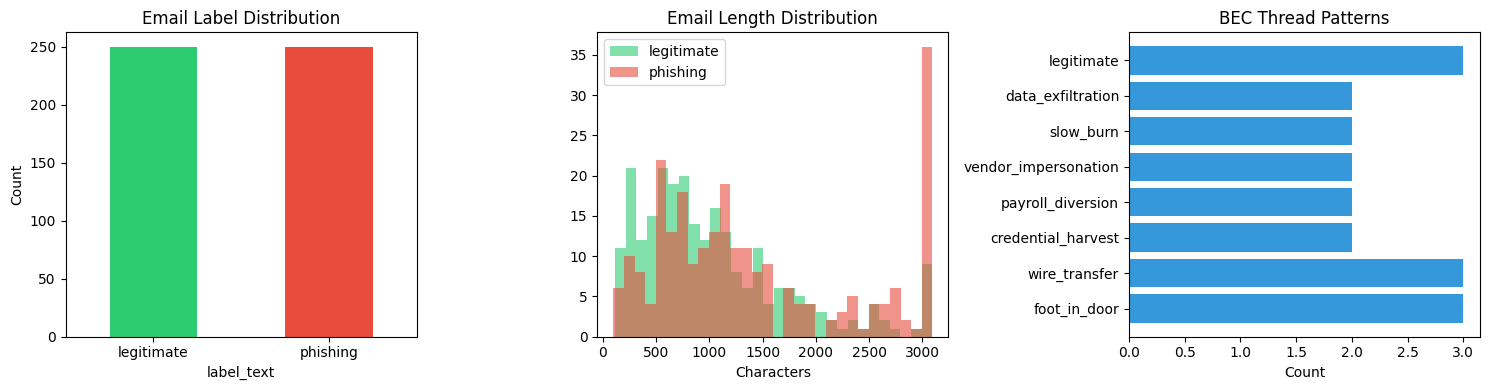

Chart saved to outputs/01_data_overview.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Label distribution
df['label_text'].value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Email Label Distribution')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Plot 2: Email length distribution by label
for label, color in [('legitimate', '#2ecc71'), ('phishing', '#e74c3c')]:
    subset = df[df['label_text'] == label]['email_text'].str.len()
    axes[1].hist(subset, bins=30, alpha=0.6, label=label, color=color)
axes[1].set_title('Email Length Distribution')
axes[1].set_xlabel('Characters')
axes[1].legend()

# Plot 3: BEC patterns
pattern_names = list(patterns.keys())
pattern_counts = list(patterns.values())
axes[2].barh(pattern_names, pattern_counts, color='#3498db')
axes[2].set_title('BEC Thread Patterns')
axes[2].set_xlabel('Count')

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'outputs/01_data_overview.png'), dpi=150)
plt.show()
print("Chart saved to outputs/01_data_overview.png")

In [8]:
print("=" * 50)
print("NOTEBOOK 1 COMPLETE - Data Preparation Summary")
print("=" * 50)
print("")
print("Files created:")
print("  data/processed/combined_dataset.csv  (500 emails, 9 columns)")
print("  data/processed/train.csv             (400 emails)")
print("  data/processed/test.csv              (100 emails)")
print("  data/processed/emails_dataset.csv    (original raw)")
print("  data/bec_threads/bec_conversations.json (19 threads)")
print("  outputs/01_data_overview.png         (visualization)")
print("")
print("Schema: id, subject, body, label, label_text,")
print("        email_text, email_type, rewrite_level, original_id")
print("")
print("Next: Notebook 2 - Adversarial Rewriting")
print("  -> Takes the 250 phishing emails and rewrites them")
print("     at 3 difficulty levels using an LLM")

NOTEBOOK 1 COMPLETE - Data Preparation Summary

Files created:
  data/processed/combined_dataset.csv  (500 emails, 9 columns)
  data/processed/train.csv             (400 emails)
  data/processed/test.csv              (100 emails)
  data/processed/emails_dataset.csv    (original raw)
  data/bec_threads/bec_conversations.json (19 threads)
  outputs/01_data_overview.png         (visualization)

Schema: id, subject, body, label, label_text,
        email_text, email_type, rewrite_level, original_id

Next: Notebook 2 - Adversarial Rewriting
  -> Takes the 250 phishing emails and rewrites them
     at 3 difficulty levels using an LLM
